In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("Real Estate Data V21.csv")
df.shape

(14528, 9)

In [3]:
df.head()

,Name,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony
0,Casagrand ECR 14,"4 BHK Flat for sale in Kanathur Reddikuppam, C...",₹1.99 Cr,"Kanathur Reddikuppam, Chennai",2583,7700.0,Best 4 BHK Apartment for modern-day lifestyle ...,4,Yes
1,"Ramanathan Nagar, Pozhichalur,Chennai",10 BHK Independent House for sale in Pozhichal...,₹2.25 Cr,"Ramanathan Nagar, Pozhichalur,Chennai",7000,3210.0,Looking for a 10 BHK Independent House for sal...,6,Yes
2,DAC Prapthi,"3 BHK Flat for sale in West Tambaram, Chennai",₹1.0 Cr,"Kasthuribai Nagar, West Tambaram,Chennai",1320,7580.0,"Property for sale in Tambaram, Chennai. This 3...",3,No
3,"Naveenilaya,Chepauk, Triplicane,Chennai",7 BHK Independent House for sale in Triplicane...,₹3.33 Cr,"Naveenilaya,Chepauk, Triplicane,Chennai",4250,7840.0,Entire Building for sale with 7 units of singl...,5,Yes
4,VGN Spring Field Phase 1,"2 BHK Flat for sale in Avadi, Chennai",₹48.0 L,"Avadi, Chennai",960,5000.0,"Property for sale in Avadi, Chennai. This 2 BH...",3,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14528 entries, 0 to 14527
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            14528 non-null  object 
 1   Property Title  14528 non-null  object 
 2   Price           14528 non-null  object 
 3   Location        14528 non-null  object 
 4   Total_Area      14528 non-null  int64  
 5   Price_per_SQFT  14528 non-null  float64
 6   Description     14528 non-null  object 
 7   Baths           14528 non-null  int64  
 8   Balcony         14528 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 1021.6+ KB


In [5]:
df.describe()

,Total_Area,Price_per_SQFT,Baths
count,14528.000000,14528.000000,14528.000000
mean,1297.916988,11719.456222,2.751239
std,1245.694305,49036.068632,0.898243
min,70.000000,0.000000,1.000000
25%,650.000000,4480.000000,2.000000
50%,1000.000000,6050.000000,3.000000
75%,1439.000000,9312.500000,3.000000
max,35000.000000,999000.000000,6.000000


In [6]:
df.isnull().sum()

Name              0
Property Title    0
Price             0
Location          0
Total_Area        0
Price_per_SQFT    0
Description       0
Baths             0
Balcony           0
dtype: int64

In [7]:
df.head()
df[~df['Price'].str.contains('L|CR',case=False)].index
df = df.drop(index=[4277, 5856, 7948, 14491])

In [8]:
def clean_price(price):
    if pd.isnull(price):
        return None
    
    price = str(price).replace('₹', '').strip().lower()
    price = price.replace('lacs', 'l').replace('lac', 'l').replace('acs', 'l')
    
    try:
        if 'cr' in price:
            return float(price.replace('cr', '').strip()) * 10000000
        elif 'l' in price:
            return float(price.replace('l', '').strip()) * 100000
        elif 'k' in price:
            return float(price.replace('k', '').strip()) * 1000
        else:
            return None
    except:
        return None
df['Price']=df['Price'].apply(clean_price)
df = df.dropna(subset=['Price'])
df['Price'] = df['Price'].astype(int)
df['Balcony'] = df['Balcony'].map({'Yes': 1, 'No': 0})
df['Price'] = df['Price'] / 10000000

In [9]:
df[df['Total_Area']>20000]
df.head()

,Name,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony
0,Casagrand ECR 14,"4 BHK Flat for sale in Kanathur Reddikuppam, C...",1.99,"Kanathur Reddikuppam, Chennai",2583,7700.0,Best 4 BHK Apartment for modern-day lifestyle ...,4,1
1,"Ramanathan Nagar, Pozhichalur,Chennai",10 BHK Independent House for sale in Pozhichal...,2.25,"Ramanathan Nagar, Pozhichalur,Chennai",7000,3210.0,Looking for a 10 BHK Independent House for sal...,6,1
2,DAC Prapthi,"3 BHK Flat for sale in West Tambaram, Chennai",1.00,"Kasthuribai Nagar, West Tambaram,Chennai",1320,7580.0,"Property for sale in Tambaram, Chennai. This 3...",3,0
3,"Naveenilaya,Chepauk, Triplicane,Chennai",7 BHK Independent House for sale in Triplicane...,3.33,"Naveenilaya,Chepauk, Triplicane,Chennai",4250,7840.0,Entire Building for sale with 7 units of singl...,5,1
4,VGN Spring Field Phase 1,"2 BHK Flat for sale in Avadi, Chennai",0.48,"Avadi, Chennai",960,5000.0,"Property for sale in Avadi, Chennai. This 2 BH...",3,1


In [10]:
df['BHK']=df['Property Title'].str.split().str[0]
def clean_bhk(val):
    val = str(val).strip().lower()
    
    if val == 'studio':
        return 1   # studio = 1 room
    
    if val == 'shop':
        return np.nan   # not residential
    
    val = val.replace('+', '')  # '5+' → '5'
    
    try:
        return float(val)
    except:
        return np.nan
df['BHK'] = df['BHK'].apply(clean_bhk)
df.head()

,Name,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony,BHK
0,Casagrand ECR 14,"4 BHK Flat for sale in Kanathur Reddikuppam, C...",1.99,"Kanathur Reddikuppam, Chennai",2583,7700.0,Best 4 BHK Apartment for modern-day lifestyle ...,4,1,4.0
1,"Ramanathan Nagar, Pozhichalur,Chennai",10 BHK Independent House for sale in Pozhichal...,2.25,"Ramanathan Nagar, Pozhichalur,Chennai",7000,3210.0,Looking for a 10 BHK Independent House for sal...,6,1,10.0
2,DAC Prapthi,"3 BHK Flat for sale in West Tambaram, Chennai",1.00,"Kasthuribai Nagar, West Tambaram,Chennai",1320,7580.0,"Property for sale in Tambaram, Chennai. This 3...",3,0,3.0
3,"Naveenilaya,Chepauk, Triplicane,Chennai",7 BHK Independent House for sale in Triplicane...,3.33,"Naveenilaya,Chepauk, Triplicane,Chennai",4250,7840.0,Entire Building for sale with 7 units of singl...,5,1,7.0
4,VGN Spring Field Phase 1,"2 BHK Flat for sale in Avadi, Chennai",0.48,"Avadi, Chennai",960,5000.0,"Property for sale in Avadi, Chennai. This 2 BH...",3,1,2.0


In [11]:
df.drop(columns='Name',inplace=True)
df.head()

,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony,BHK
0,"4 BHK Flat for sale in Kanathur Reddikuppam, C...",1.99,"Kanathur Reddikuppam, Chennai",2583,7700.0,Best 4 BHK Apartment for modern-day lifestyle ...,4,1,4.0
1,10 BHK Independent House for sale in Pozhichal...,2.25,"Ramanathan Nagar, Pozhichalur,Chennai",7000,3210.0,Looking for a 10 BHK Independent House for sal...,6,1,10.0
2,"3 BHK Flat for sale in West Tambaram, Chennai",1.00,"Kasthuribai Nagar, West Tambaram,Chennai",1320,7580.0,"Property for sale in Tambaram, Chennai. This 3...",3,0,3.0
3,7 BHK Independent House for sale in Triplicane...,3.33,"Naveenilaya,Chepauk, Triplicane,Chennai",4250,7840.0,Entire Building for sale with 7 units of singl...,5,1,7.0
4,"2 BHK Flat for sale in Avadi, Chennai",0.48,"Avadi, Chennai",960,5000.0,"Property for sale in Avadi, Chennai. This 2 BH...",3,1,2.0


In [12]:
df['BHK'].value_counts()

BHK
2.0     5690
1.0     3281
3.0     3131
4.0      989
5.0      461
6.0      296
10.0     166
7.0      143
8.0      132
9.0       78
3.5       44
10.5      34
1.5       30
2.5       30
4.5       10
9.5        4
8.5        2
7.5        2
Name: count, dtype: int64

In [13]:
df['Location']=df['Location'].str.replace(',',' ')
df['City']=df['Location'].str.split().str[-1]
df.groupby('City')['Baths'].count()
df['City']=df['City'].str.replace('Thane','Mumbai')
df['City'].value_counts()
df.head()

,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony,BHK,City
0,"4 BHK Flat for sale in Kanathur Reddikuppam, C...",1.99,Kanathur Reddikuppam Chennai,2583,7700.0,Best 4 BHK Apartment for modern-day lifestyle ...,4,1,4.0,Chennai
1,10 BHK Independent House for sale in Pozhichal...,2.25,Ramanathan Nagar Pozhichalur Chennai,7000,3210.0,Looking for a 10 BHK Independent House for sal...,6,1,10.0,Chennai
2,"3 BHK Flat for sale in West Tambaram, Chennai",1.00,Kasthuribai Nagar West Tambaram Chennai,1320,7580.0,"Property for sale in Tambaram, Chennai. This 3...",3,0,3.0,Chennai
3,7 BHK Independent House for sale in Triplicane...,3.33,Naveenilaya Chepauk Triplicane Chennai,4250,7840.0,Entire Building for sale with 7 units of singl...,5,1,7.0,Chennai
4,"2 BHK Flat for sale in Avadi, Chennai",0.48,Avadi Chennai,960,5000.0,"Property for sale in Avadi, Chennai. This 2 BH...",3,1,2.0,Chennai


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14524 entries, 0 to 14527
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Property Title  14524 non-null  object 
 1   Price           14524 non-null  float64
 2   Location        14524 non-null  object 
 3   Total_Area      14524 non-null  int64  
 4   Price_per_SQFT  14524 non-null  float64
 5   Description     14524 non-null  object 
 6   Baths           14524 non-null  int64  
 7   Balcony         14524 non-null  int64  
 8   BHK             14523 non-null  float64
 9   City            14524 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 1.2+ MB


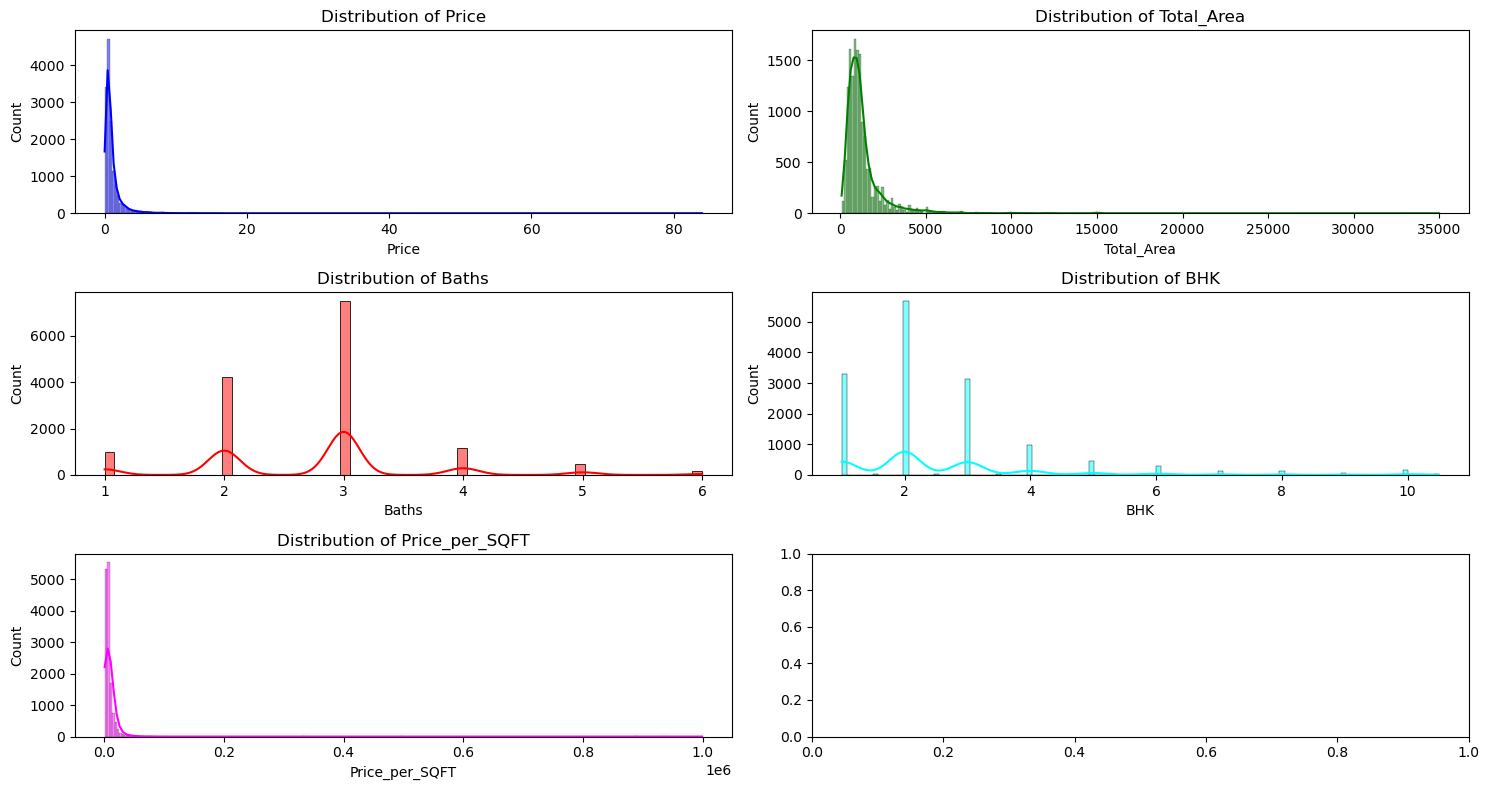

In [15]:
num_cols = ['Price', 'Total_Area', 'Baths', 'BHK', 'Price_per_SQFT']
colors=['blue', 'green', 'red', 'cyan', 'magenta',
'yellow', 'black', 'white', 'orange',
'purple', 'pink', 'brown', 'gray']
fig, axes = plt.subplots(3,2, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i],color=colors[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

<Axes: xlabel='City', ylabel='Price'>

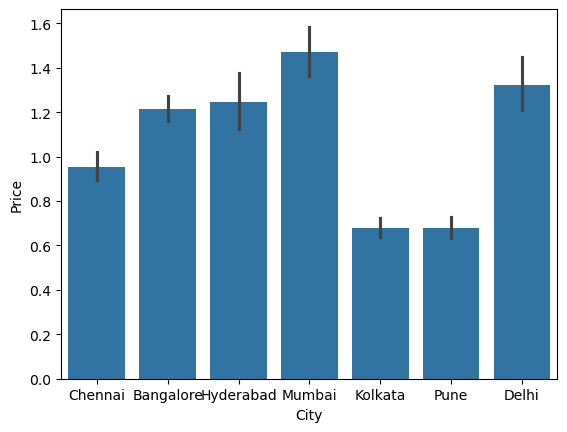

In [16]:
sns.barplot(x='City', y='Price', data=df)

<Axes: >

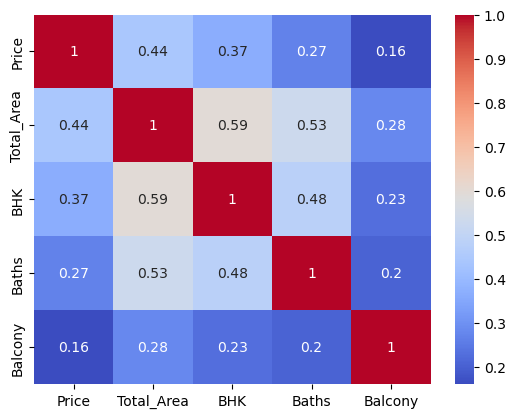

In [17]:
sns.heatmap(df[['Price','Total_Area','BHK','Baths','Balcony']].corr(),annot=True, cmap='coolwarm')

<Axes: xlabel='City', ylabel='Price'>

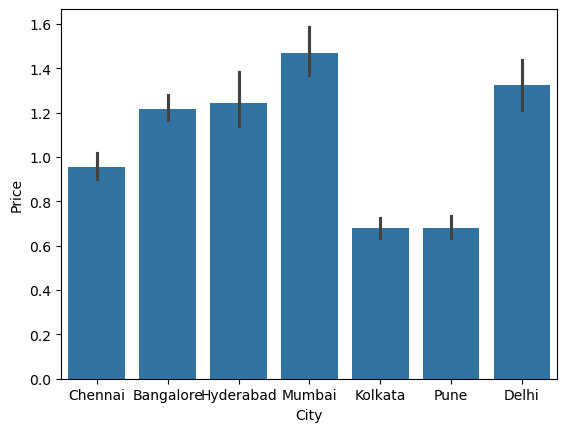

In [18]:
sns.barplot(x='City', y='Price', data=df)


<Axes: xlabel='BHK', ylabel='Price'>

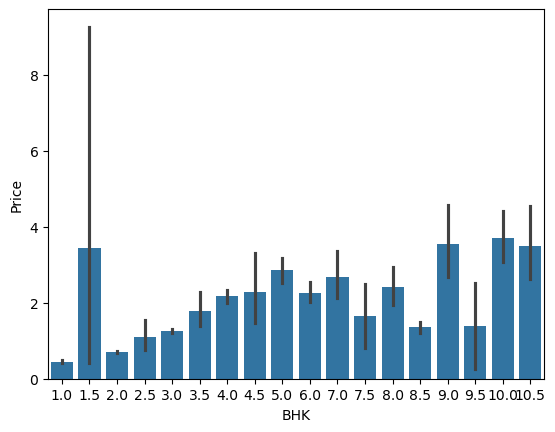

In [19]:
sns.barplot(x='BHK', y='Price', data=df)

<Axes: xlabel='Baths', ylabel='Price'>

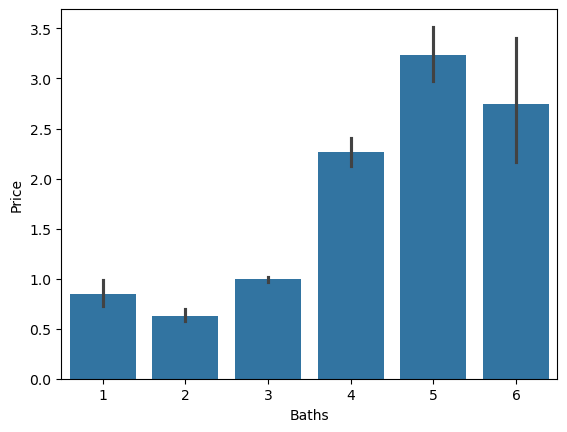

In [20]:
sns.barplot(x='Baths', y='Price', data=df)

In [24]:
df.loc[
    (df['BHK'].isna()) & (df['Baths'] == 1),
    'BHK'
] = 1

In [30]:
y = np.log(df['Price'])
X = df[['Total_Area','BHK','Baths','Balcony','City']]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.4394946108761414
R2: 0.530502383860836


In [31]:
model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.404891190935141
R2: 0.58602893664949
